In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

df = pd.read_csv('../data/listings.csv')
print(f"Loaded raw data: {df.shape}")

Loaded raw data: (22933, 79)


## Drop the dead weight

In [3]:
cols_to_drop = [
    'neighbourhood_group_cleansed',  # 100% null
    'calendar_updated',              # 100% null
    'host_about',                    # not useful for tabular ML
    'neighborhood_overview',         # free text
    'description',                   # free text
    'neighbourhood',                 # 53% null
    'license',                       # 14% null
]

df = df.drop(columns=cols_to_drop)
print(f"Shape after dropping dead columns: {df.shape}")

Shape after dropping dead columns: (22933, 72)


## Fix the price column

In [4]:
df['price'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float)
df = df.dropna(subset=['price'])

print(df['price'].describe())
print(f"\nShape after dropping null prices: {df.shape}")

count    20538.000000
mean       210.899990
std        693.894027
min          9.000000
25%         89.000000
50%        125.000000
75%        190.000000
max      65500.000000
Name: price, dtype: float64

Shape after dropping null prices: (20538, 72)


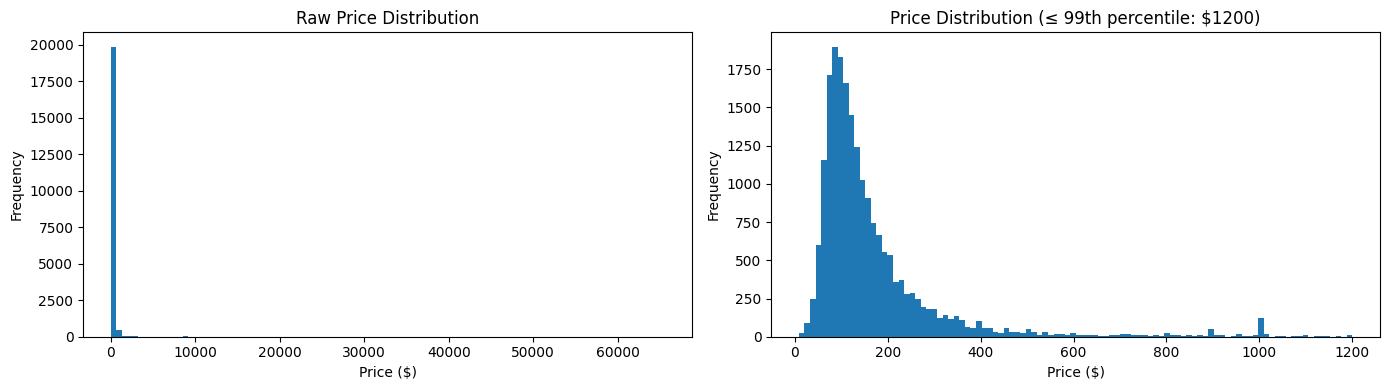


Max price: $65,500
Listings above $1000/night: 268


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Raw distribution
df['price'].plot(kind='hist', bins=100, ax=ax1, title='Raw Price Distribution')
ax1.set_xlabel('Price ($)')

# Cut off top 1%
p99 = df['price'].quantile(0.99)
df[df['price'] <= p99]['price'].plot(
    kind='hist', bins=100, ax=ax2, 
    title=f'Price Distribution (≤ 99th percentile: ${p99:.0f})'
)
ax2.set_xlabel('Price ($)')

plt.tight_layout()
plt.show()

print(f"\nMax price: ${df['price'].max():,.0f}")
print(f"Listings above $1000/night: {(df['price'] > 1000).sum()}")

## Handle Outliers and log transform

In [6]:
p99 = df['price'].quantile(0.99)
df = df[df['price']<= p99].copy()
print(f"Price cap set at ${p99:.0f}")
print(f"Shape after removing outliers: {df.shape}")


Price cap set at $1200
Shape after removing outliers: (20342, 72)


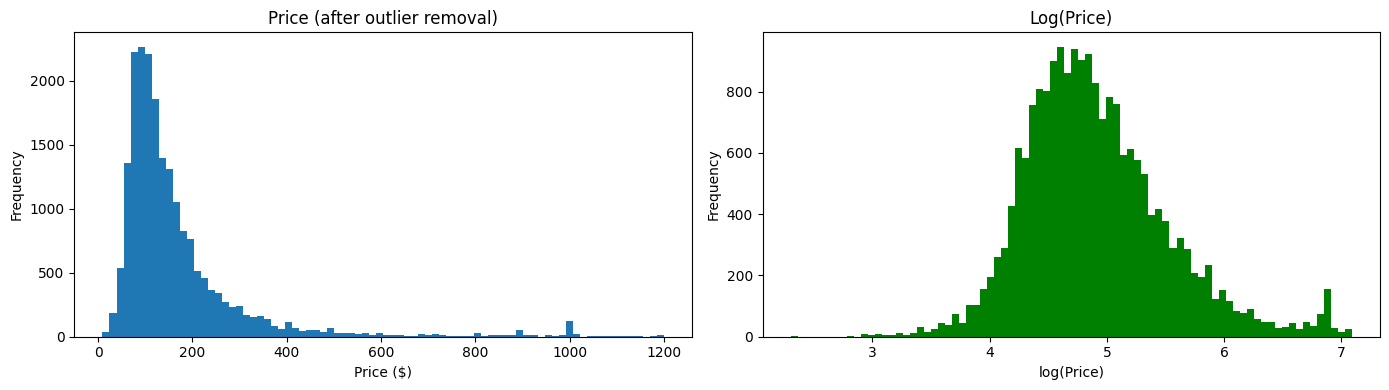

In [7]:
df['price_log'] = np.log1p(df['price'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

df['price'].plot(kind='hist', bins=80, ax=ax1, title='Price (after outlier removal)')
ax1.set_xlabel('Price ($)')

df['price_log'].plot(kind='hist', bins=80, ax=ax2, color='green',
                     title='Log(Price)')
ax2.set_xlabel('log(Price)')

plt.tight_layout()
plt.show()

## Feature columns

In [ ]:
key_cols = [
    'room_type', 'accommodates', 'bedrooms', 'beds', 
    'bathrooms_text', 'review_scores_rating', 'number_of_reviews',
    'neighbourhood_cleansed', 'latitude', 'longitude',
    'host_is_superhost', 'instant_bookable'
]

print(df[key_cols].dtypes)

print('----')



review_cols = [
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_communication', 'review_scores_location',
    'review_scores_accuracy', 'review_scores_checkin',
    'review_scores_value'
]

print(f"\nMin value in review_scores_rating: {df['review_scores_rating'].min()}")
print(f"Zero values in review_scores_rating: {(df['review_scores_rating'] == 0).sum()}")

df['review_scores_rating'] = df['review_scores_rating'].replace(0, np.nan)


room_type                  object
accommodates                int64
bedrooms                  float64
beds                      float64
bathrooms_text             object
review_scores_rating      float64
number_of_reviews           int64
neighbourhood_cleansed     object
latitude                  float64
longitude                 float64
host_is_superhost          object
instant_bookable           object
dtype: object
----

Min value in review_scores_rating: 1.0
Zero values in review_scores_rating: 0


In [18]:
df.to_csv('../data/listings_clean.csv', index=False)
print(f"Saved clean data: {df.shape[0]} rows, {df.shape[1]} columns")

Saved clean data: 20342 rows, 73 columns
